# EDA

## Key Findings

1. Dataset contains 7043 customer records and 21 features.
2. Target variable is Churn.
3. Churn distribution is approximately:
   - No Churn: 74%
   - Churn: 26%
4. No missing values were present initially.
5. TotalCharges was incorrectly stored as an object.
6. After conversion, 11 missing values were identified.
7. Missing values were removed using dropna().
8. Dataset is now clean and ready for feature analysis and modeling.

## Key Insights

1. The dataset contains moderate class imbalance (26% churn).
2. Month-to-Month contracts have the highest churn rate.
3. Customers with low tenure are more likely to churn.
4. Higher monthly charges are associated with increased churn.
5. Fiber Optic users show relatively higher churn.
6. No single feature strongly explains churn, indicating the need for machine learning models to capture complex relationships.

In [14]:
# Importing libraries required for data loading and analysis.

import pandas as pd

# Read the Telco Customer Churn dataset into a Pandas DataFrame.

df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

# Understanding the structure and sample values of the data set
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# Checing the number of rows and columns
df.shape

(7043, 21)

In [16]:
# Examinig columns names, datatype and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
# understanding the distribution if numerical features
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Listing all avialable features
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [ ]:
# To know churn Distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
# Checking for missing values in each feature
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
# Inspecting the Total Charges Column
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [17]:
# Verifying whether features is stored as numeric
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [ ]:
# COnverting Total charges columns into numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
# Idenitifying missing values introduced during conversion
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:
# Removing rows containing missing values
df.dropna(inplace=True)

In [ ]:
# Confirming that no missing values remain
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Churn Distribution

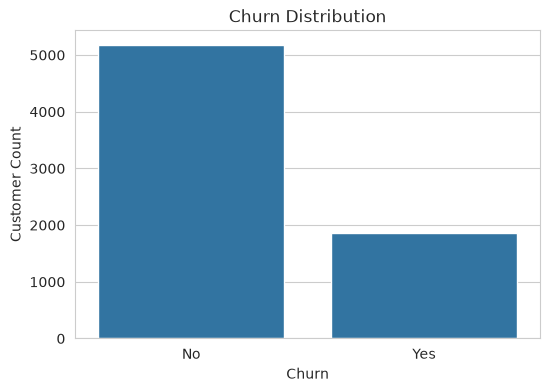

In [19]:
# Understanding class balance in the target variable
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")

plt.show()

Approximately 26% of customers churned while 74% remained,
indicating moderate class imbalance.

# Contract Type vs Churn


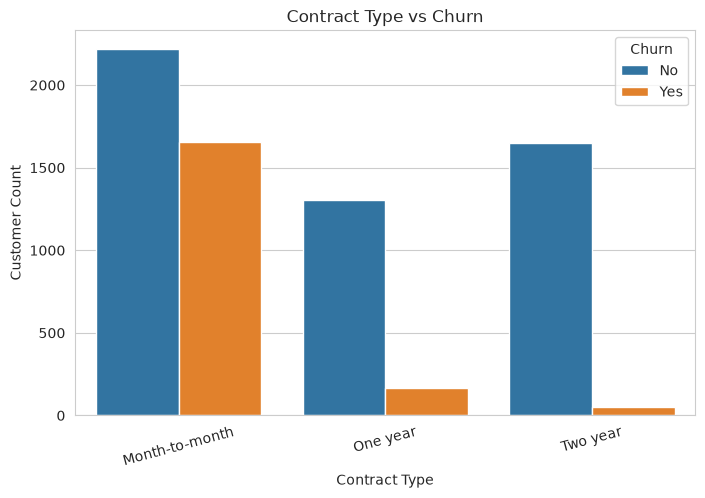

In [20]:
# analyzing whether contract type influences churn
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")

plt.xticks(rotation=15)

plt.show()

Customers with Month-to-Month contracts show significantly
higher churn compared to One-Year and Two-Year contracts.

# Tenure Distribution

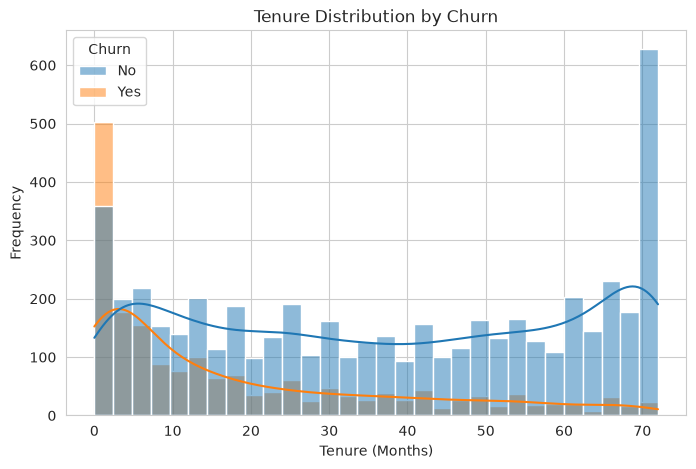

In [21]:
# Understainding how customer tenure relates to churn
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True,
    bins=30
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.show()

Customers with shorter tenure are more likely to churn,
while long-term customers tend to stay.

# Monthly Charges vs Churn

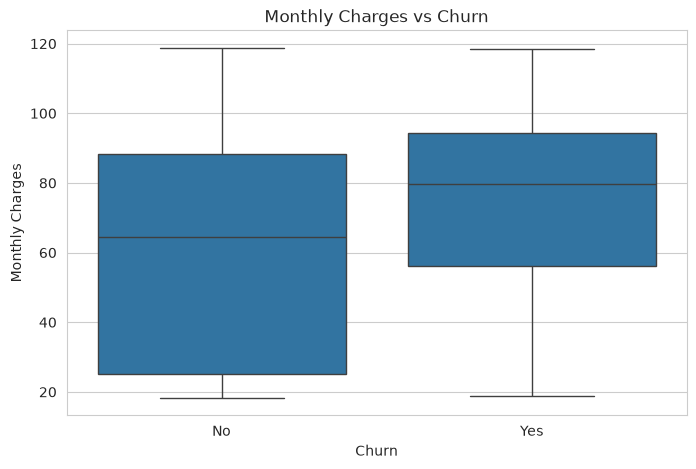

In [22]:
# Comparing monthly charges between churned and retained customers
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Customers with higher monthly charges appear more likely to churn.

# Internet Service vs Churn


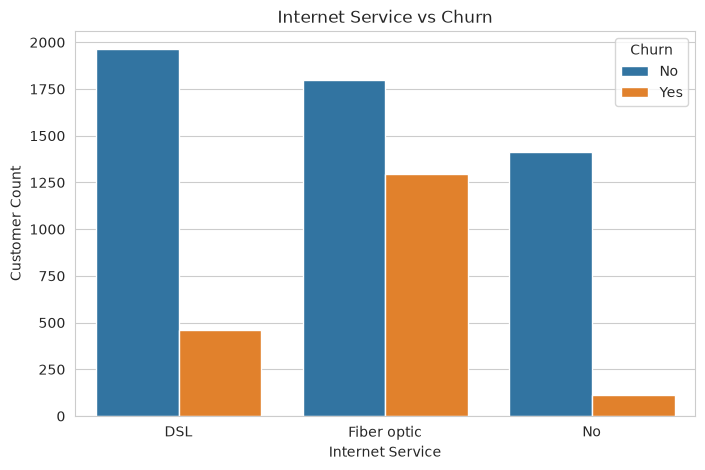

In [23]:
# Analyzing the churn across internet Service categories
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")

plt.show()

Fiber Optic customers exhibit higher churn rates
compared to DSL customers.

# Correlation Heatmap

In [25]:
# creating ecncoded numerical data
corr_df = df.copy()

for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col] = corr_df[col].astype("category").cat.codes

/tmp/ipykernel_20170/3505239044.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in corr_df.select_dtypes(include="object").columns:


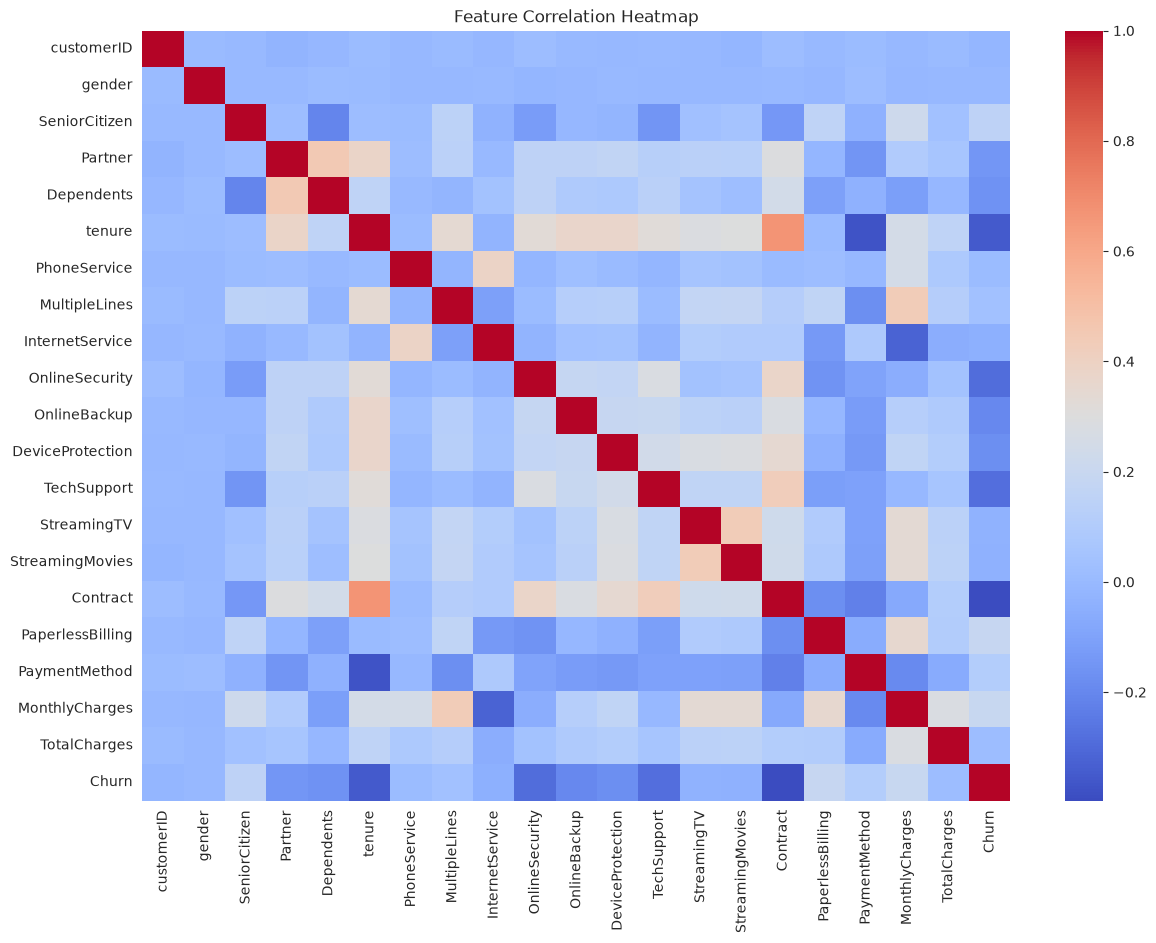

In [26]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.show()

Most features show weak correlation individually,
suggesting that multiple factors contribute to customer churn.

# Feature Selection

In [27]:
# Customer id as no predictive value
df.drop("customerID", axis=1, inplace=True)

In [28]:
# verufying 
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
